In [2]:
# Core libraries used throughout the analysis
import numpy as np                 # numerical computing
import pandas as pd                # data tables (DataFrame)
import matplotlib.pyplot as plt    # plotting
from scipy import stats            # statistical tests and functions

In [3]:
# Load the training set (the target column "price_range" is available here)
df = pd.read_csv("train.csv")

# First rows: get a feel for the structure
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [4]:
# Shape = (rows, columns) and the data type of every column
print("Shape:", df.shape)
print("\nData types:")
print(df.dtypes)

Shape: (2000, 21)

Data types:
battery_power      int64
blue               int64
clock_speed      float64
dual_sim           int64
fc                 int64
four_g             int64
int_memory         int64
m_dep            float64
mobile_wt          int64
n_cores            int64
pc                 int64
px_height          int64
px_width           int64
ram                int64
sc_h               int64
sc_w               int64
talk_time          int64
three_g            int64
touch_screen       int64
wifi               int64
price_range        int64
dtype: object


In [5]:
# Descriptive statistics for every numeric column (count, mean, std, min, quartiles, max)
df.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
count,2000.000000,2000.0000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1238.518500,0.4950,1.522250,0.509500,4.309500,0.521500,32.046500,0.501750,140.249000,4.520500,...,645.108000,1251.515500,2124.213000,12.306500,5.767000,11.011000,0.761500,0.503000,0.507000,1.500000
std,439.418206,0.5001,0.816004,0.500035,4.341444,0.499662,18.145715,0.288416,35.399655,2.287837,...,443.780811,432.199447,1084.732044,4.213245,4.356398,5.463955,0.426273,0.500116,0.500076,1.118314
min,501.000000,0.0000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,...,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,851.750000,0.0000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,...,282.750000,874.750000,1207.500000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000,0.750000
50%,1226.000000,0.0000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,141.000000,4.000000,...,564.000000,1247.000000,2146.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000,1.500000
75%,1615.250000,1.0000,2.200000,1.000000,7.000000,1.000000,48.000000,0.800000,170.000000,7.000000,...,947.250000,1633.000000,3064.500000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000,2.250000
max,1998.000000,1.0000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,...,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000,3.000000


In [6]:
# The target "price_range" has 4 ordered classes:
# 0 = low cost, 1 = medium, 2 = high, 3 = very high cost
df["price_range"].value_counts().sort_index()

price_range
0    500
1    500
2    500
3    500
Name: count, dtype: int64

In [7]:
# 1) Missing / null values per column
df.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [8]:
# 2) Duplicated rows
print("Duplicated rows:", df.duplicated().sum())

# 3) Non-numeric (text/categorical) columns that would need encoding
print("Text (object) columns:", list(df.select_dtypes(include="object").columns))

Duplicated rows: 0
Text (object) columns: []


In [9]:
# All columns are already numeric and there are no missing values,
# so no imputation or encoding is required.
# The binary features (blue, dual_sim, four_g, three_g, touch_screen, wifi)
# are already encoded as 0/1.

# For clearer plots and reports, add a readable text label for the target.
price_labels = {0: "Low", 1: "Medium", 2: "High", 3: "Very High"}
df["price_label"] = df["price_range"].map(price_labels)
df[["price_range", "price_label"]].head()

,price_range,price_label
0,1,Medium
1,2,High
2,2,High
3,2,High
4,1,Medium


In [10]:
# Continuous features we analyse in detail
continuous = ["battery_power", "clock_speed", "fc", "int_memory", "m_dep",
              "mobile_wt", "n_cores", "pc", "px_height", "px_width", "ram",
              "sc_h", "sc_w", "talk_time"]

# Central tendency: mean, median, mode
summary = pd.DataFrame(index=continuous)
summary["mean"]   = [np.mean(df[c]) for c in continuous]        # average
summary["median"] = [np.median(df[c]) for c in continuous]      # middle value
summary["mode"]   = [df[c].mode().iloc[0] for c in continuous]  # most frequent value
summary.round(2)

,mean,median,mode
battery_power,1238.52,1226.0,618.0
clock_speed,1.52,1.5,0.5
fc,4.31,3.0,0.0
int_memory,32.05,32.0,27.0
m_dep,0.50,0.5,0.1
mobile_wt,140.25,141.0,182.0
n_cores,4.52,4.0,4.0
pc,9.92,10.0,10.0
px_height,645.11,564.0,347.0
px_width,1251.52,1247.0,874.0


In [11]:
# Variability: range (max - min), variance and standard deviation
summary["range"]    = [df[c].max() - df[c].min() for c in continuous]
summary["variance"] = [np.var(df[c], ddof=1) for c in continuous]   # sample variance
summary["std"]      = [np.std(df[c], ddof=1) for c in continuous]   # sample std
summary.round(2)

,mean,median,mode,range,variance,std
battery_power,1238.52,1226.0,618.0,1497.0,193088.36,439.42
clock_speed,1.52,1.5,0.5,2.5,0.67,0.82
fc,4.31,3.0,0.0,19.0,18.85,4.34
int_memory,32.05,32.0,27.0,62.0,329.27,18.15
m_dep,0.50,0.5,0.1,0.9,0.08,0.29
mobile_wt,140.25,141.0,182.0,120.0,1253.14,35.40
n_cores,4.52,4.0,4.0,7.0,5.23,2.29
pc,9.92,10.0,10.0,20.0,36.78,6.06
px_height,645.11,564.0,347.0,1960.0,196941.41,443.78
px_width,1251.52,1247.0,874.0,1498.0,186796.36,432.20


In [12]:
# Distribution shape: skewness (asymmetry) and kurtosis (tailedness, excess -> normal = 0)
summary["skew"]     = [stats.skew(df[c]) for c in continuous]
summary["kurtosis"] = [stats.kurtosis(df[c]) for c in continuous]
summary.round(2)

,mean,median,mode,range,variance,std,skew,kurtosis
battery_power,1238.52,1226.0,618.0,1497.0,193088.36,439.42,0.03,-1.22
clock_speed,1.52,1.5,0.5,2.5,0.67,0.82,0.18,-1.32
fc,4.31,3.0,0.0,19.0,18.85,4.34,1.02,0.27
int_memory,32.05,32.0,27.0,62.0,329.27,18.15,0.06,-1.22
m_dep,0.50,0.5,0.1,0.9,0.08,0.29,0.09,-1.27
mobile_wt,140.25,141.0,182.0,120.0,1253.14,35.40,0.01,-1.21
n_cores,4.52,4.0,4.0,7.0,5.23,2.29,0.00,-1.23
pc,9.92,10.0,10.0,20.0,36.78,6.06,0.02,-1.17
px_height,645.11,564.0,347.0,1960.0,196941.41,443.78,0.67,-0.32
px_width,1251.52,1247.0,874.0,1498.0,186796.36,432.20,0.01,-1.19


In [13]:
# HYPOTHESIS TEST 1 - ANOVA
# H0: the mean RAM is the same across the 4 price ranges.
# H1: at least one price range has a different mean RAM.
groups = [df[df["price_range"] == k]["ram"] for k in range(4)]
f_stat, p_value = stats.f_oneway(*groups)

print("Mean RAM per price range:")
print(df.groupby("price_range")["ram"].mean().round(1))
print("\nANOVA  F = %.2f   p = %.3e" % (f_stat, p_value))

if p_value < 0.05:
    print("=> Reject H0: RAM differs significantly across price ranges.")
else:
    print("=> Fail to reject H0.")

Mean RAM per price range:
price_range
0     785.3
1    1679.5
2    2582.8
3    3449.2
Name: ram, dtype: float64

ANOVA  F = 3520.11   p = 0.000e+00
=> Reject H0: RAM differs significantly across price ranges.


In [14]:
# HYPOTHESIS TEST 2 - two-sample t-test
# Compare RAM between the cheapest (0) and the most expensive (3) phones.
ram_low  = df[df["price_range"] == 0]["ram"]
ram_high = df[df["price_range"] == 3]["ram"]
t_stat, p_value = stats.ttest_ind(ram_low, ram_high)

print("Mean RAM  low =", round(ram_low.mean(), 1), " | very high =", round(ram_high.mean(), 1))
print("t = %.2f   p = %.3e" % (t_stat, p_value))

if p_value < 0.05:
    print("=> Significant difference (reject H0).")
else:
    print("=> No significant difference.")

Mean RAM  low = 785.3  | very high = 3449.2
t = -111.37   p = 0.000e+00
=> Significant difference (reject H0).


In [ ]:
# CORRELATION with the target, ranked from strongest to weakest
numeric_df = df.select_dtypes(include=[np.number])
corr_with_target = numeric_df.corr()["price_range"].drop("price_range")
print(corr_with_target.sort_values(ascending=False).round(3))

# SciPy returns the coefficient AND its p-value for the strongest driver (RAM)
r, p_value = stats.pearsonr(df["ram"], df["price_range"])
print("\nPearson r (ram vs price_range) = %.3f   p = %.3e" % (r, p_value))

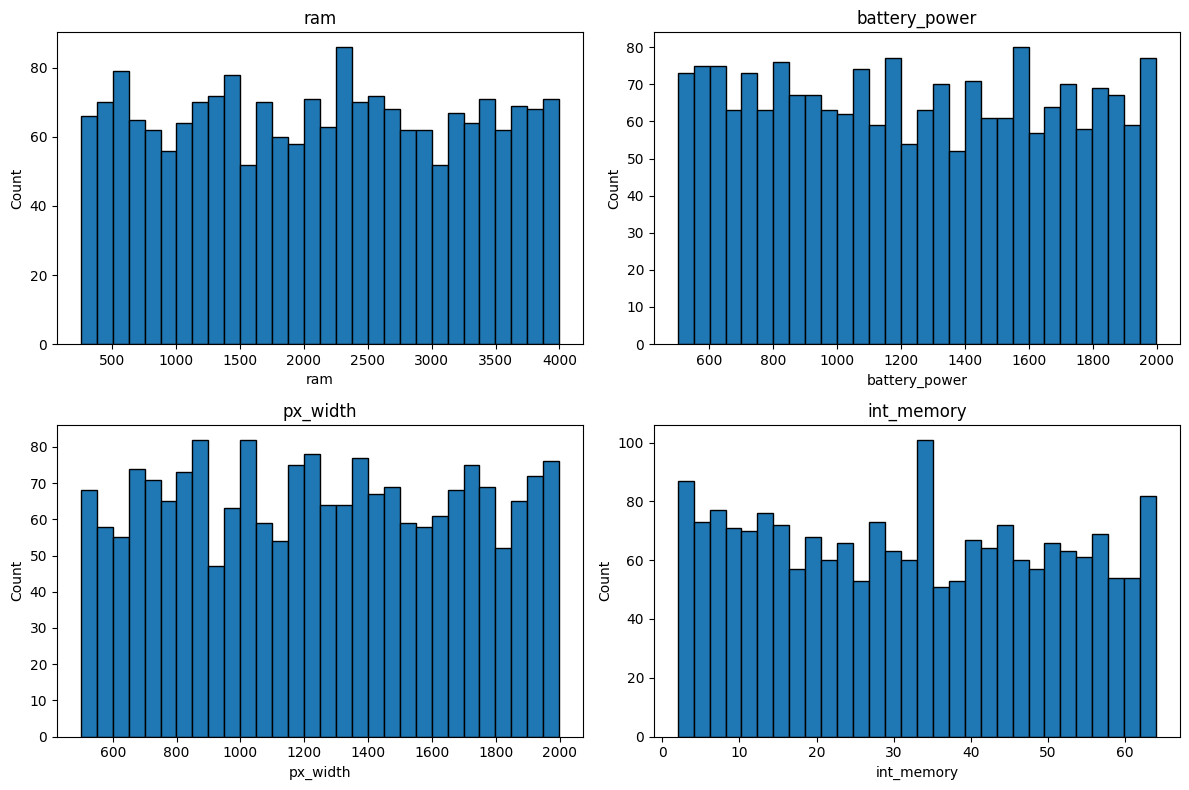

In [15]:
# Histograms: distribution of a few important features
features = ["ram", "battery_power", "px_width", "int_memory"]
plt.figure(figsize=(12, 8))
for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)                      # 2x2 grid of sub-plots
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

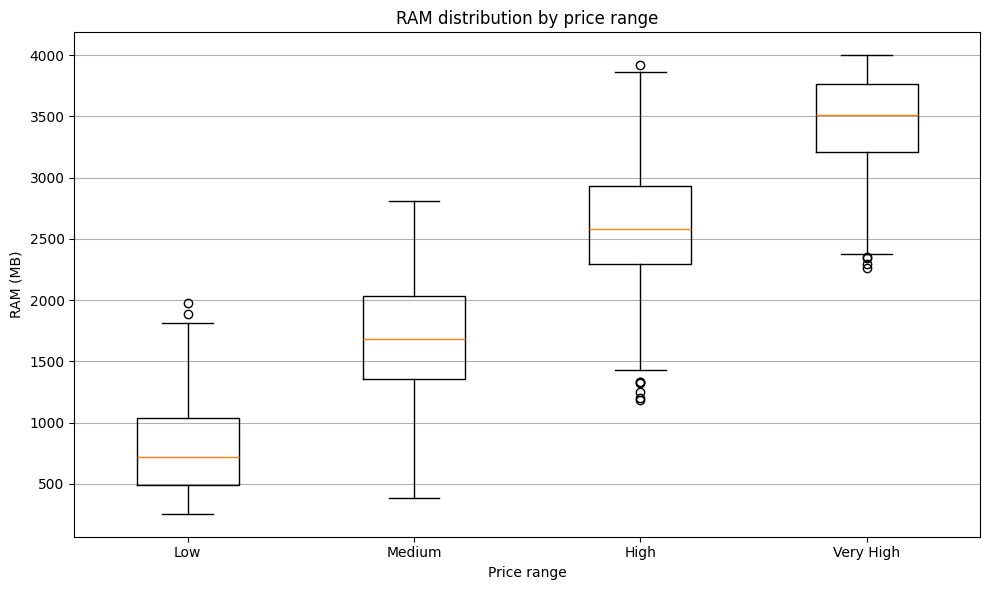

In [16]:
# Box plot: how RAM is distributed within each price range
data_by_class = [df[df["price_range"] == k]["ram"] for k in range(4)]
plt.figure(figsize=(10, 6))
plt.boxplot(data_by_class)                    # default positions are 1..4
plt.xticks([1, 2, 3, 4], ["Low", "Medium", "High", "Very High"])
plt.title("RAM distribution by price range")
plt.xlabel("Price range")
plt.ylabel("RAM (MB)")
plt.grid(True, axis="y")
plt.tight_layout()
plt.show()

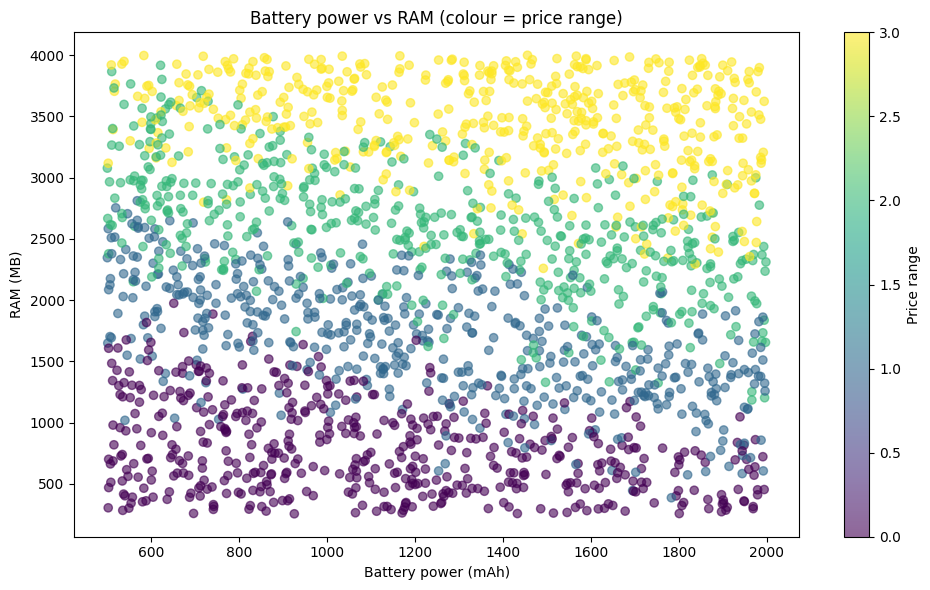

In [17]:
# Scatter plot: battery_power vs RAM, coloured by price range
plt.figure(figsize=(10, 6))
sc = plt.scatter(df["battery_power"], df["ram"], c=df["price_range"],
                 cmap="viridis", alpha=0.6)
plt.colorbar(sc, label="Price range")
plt.title("Battery power vs RAM (colour = price range)")
plt.xlabel("Battery power (mAh)")
plt.ylabel("RAM (MB)")
plt.tight_layout()
plt.show()

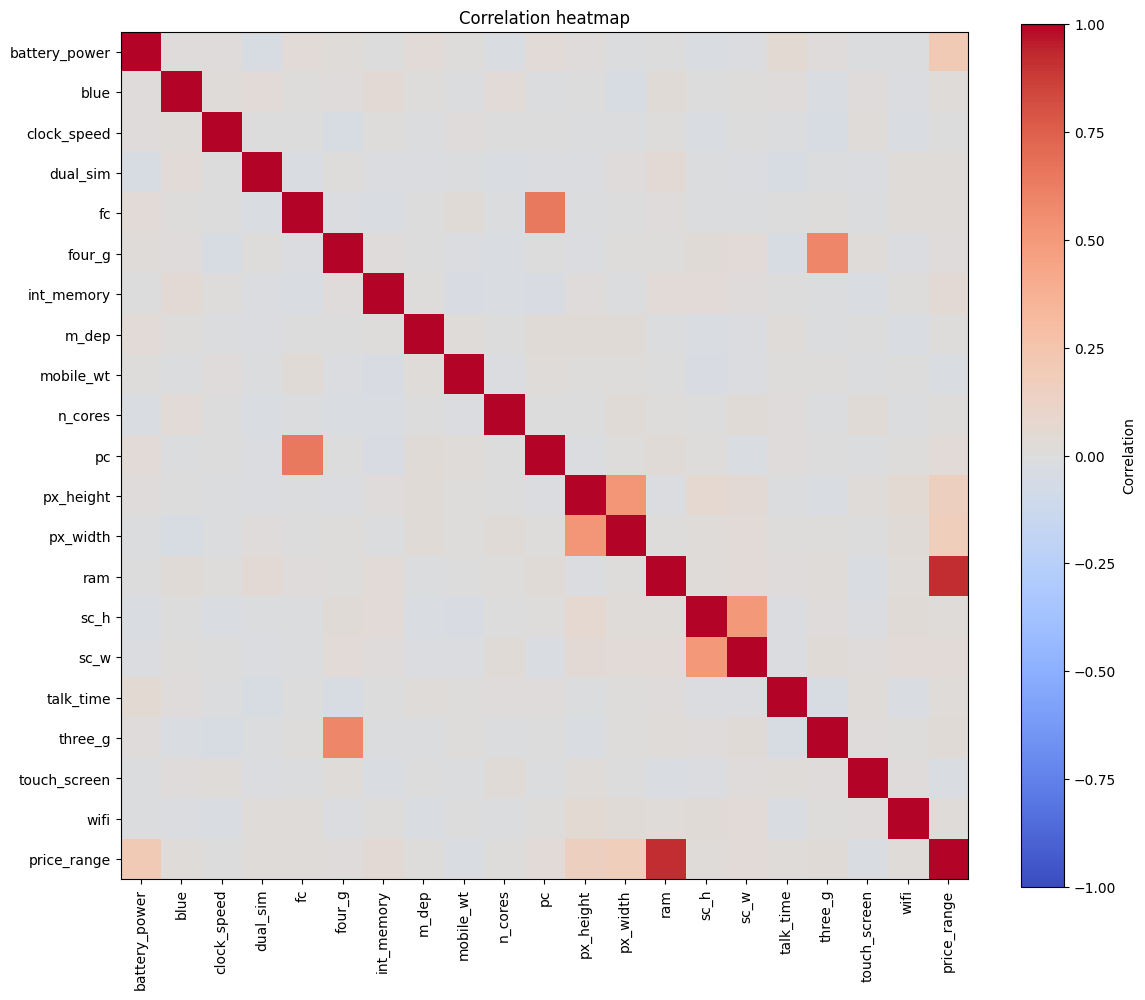

In [22]:
# Correlation heatmap of all numeric features (matplotlib only, no seaborn)
numeric_df = df.select_dtypes(include=[np.number])   # colonnes numériques uniquement
corr = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, label="Correlation")
plt.title("Correlation heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# Bar chart: correlation of each feature with the target (highlights the drivers)
corr = df.select_dtypes(include=[np.number]).corr()
corr_sorted = corr["price_range"].drop("price_range").sort_values()
plt.figure(figsize=(10, 7))
plt.barh(corr_sorted.index, corr_sorted.values, color="teal")
plt.title("Correlation of each feature with price_range")
plt.xlabel("Pearson correlation")
plt.tight_layout()
plt.show()



#**Dataset quality**
#- 2,000 phones, 20 features, 1 target. No missing values, no duplicates, and the four
  price classes are perfectly balanced (500 each).

**The dominant driver: RAM**
##- Mean RAM rises steadily with price: **785 -> 1,680 -> 2,583 -> 3,449 MB**.
#- ANOVA (F = 3520, p ~ 0) and the t-test between the cheapest and most expensive phones
#(t = -111, p ~ 0) both confirm the difference is highly significant.

#**Secondary drivers**
#- `battery_power` (0.20), `px_width` (0.17) and `px_height` (0.15) show weak but real
 #positive correlations with price.
#- All remaining features (cores, cameras, connectivity flags, weight, depth...) are
 #essentially uncorrelated with the price range (|r| < 0.05).

#**Distribution shapes**
#- Most features are almost uniform (skew ~ 0, kurtosis ~ -1.2), typical of this synthetic
  #dataset. `fc`, `px_height` and `sc_w` are right-skewed.

**Unexpected finding**
#- Intuitively "premium" specs such as number of cores, clock speed and camera megapixels
  barely affect the price class - **memory size dominates everything**.

**Conclusion**
-# To classify a phone's price range, **RAM is the single most important feature**, with
  #battery power and screen resolution as minor contributors. A model based on RAM alone
  #would already separate the classes very well.